**N1_calibration:** Notebook for calibration of visibilities from all antennas in a given observation, as well as generating the background temperature templates.

## 1. Initialization

Initialize the computation with the necessary modules.

In [3]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [4]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.data_reductionNEW as dr
import sys
sys.path.insert(0, './initialization/')
from imports import *
import parameters as pm  # <-- don't import for python2


## 2. Creating katdal file (python2 only!)

In order to obtain information that needs the katdal module, we need to use the python2 singularity (the python3 singularity is not compatible with the module for some reason). As such, this specific section is written in python2 and performs all computations necessary to create the katdal file with all of the information; afterwards, we just need to retrieve the file and can use python3 from the next section onward.


In [12]:
# generating katdal information file
block = 1551055211
path_results = "results_calibration/{}/".format(block)
katdal_info, obs_data = dr.generate_katdal_file(block, path_results, verbose=True)


Getting file with katdal...
Getting nd timestamps...


In [17]:
# saving information that is needed from the python2 katdal module
pickle.dump(katdal_info, open(path_results + "katdal_info.p", 'wb')) 
pickle.dump(obs_data.ants, open(path_results + "antennas.p", "wb")) 


## 3. Background temperature models

We now make use of the existing calibration files on the background model in each antenna (for the unflagged regions) and then calibrate the bands that are of interest and that have been flagged from the calibration. We start by uploading the background calibrated files (which are null in the parts flagged by RFI); this takes up a lot of space, some 30GBs.

In [5]:
# to debug we only analyse N_debug antennas; later put this to None or remove from the code entirely
N_debug = 1


In [6]:
# initializing data reduction object
DR = dr.DataReduction(
    block = pm.block, 
    path_cali = pm.path_cali,
    freq_range = pm.freq_range
)


In [7]:
# getting background temperatures
Trec,Tgal,Tmap,mask = DR.get_background_raws("L4", N_debug=N_debug)


Retrieving data from antennas...
	Antenna m000 successful.


### A. Receiver temperature

Now, we perform calibration on the receiver temperature of each good antenna; we assume the mask of unvalid values is given by mask, and perform interpolation of the values that we have from Trec.

For the frequency-average, the level 4 mask also masks some entire time-stamps besides the usual RFI flagging of the frequency regions; however, if we use the "correctly" masked array, we return a very spotty and weird time curve since we now have some timestamps with very little points. If, instead, we just use the natural zero's mask (the data naturally has some spots where the temperature wasn't put in and it's just zeros), then we return a curve that is almost exactly like the one before, only now it's normal in its shape. As such, we will use this "incorrect" mask for the time curve. 

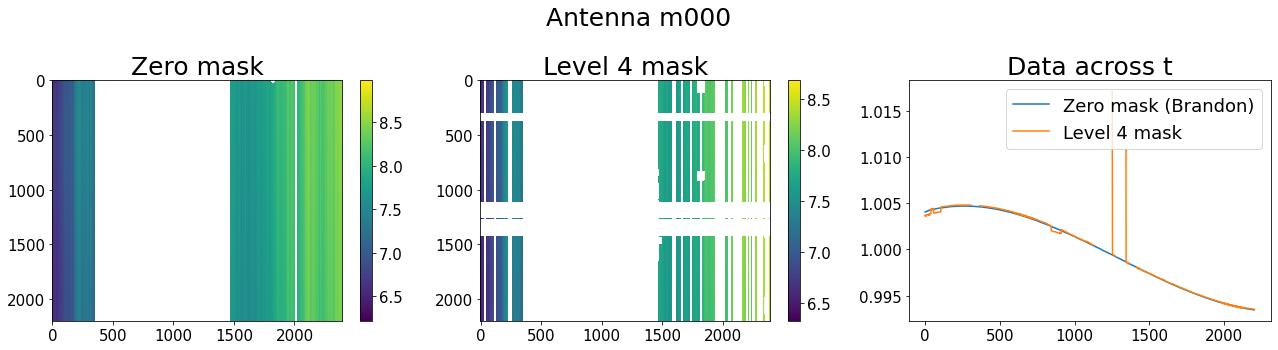

In [17]:
# comparing the two possible maskings for the time curve (frequency average)
for i in range(N_debug):

    # quantities
    T = Trec[i][0]
    Trec_true = np.ma.masked_array(T, mask=mask[i])
    Trec_zeros = np.ma.masked_array(T, mask=(T==0))

    # plots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    im1 = ax1.imshow(Trec_zeros, aspect="auto")
    fig.colorbar(im1, ax=ax1)
    ax1.set_title("Zero mask")
    im2 = ax2.imshow(Trec_true, aspect="auto")
    fig.colorbar(im2, ax=ax2)
    ax2.set_title("Level 4 mask")
    ax3.plot(np.ma.mean(Trec_zeros, axis=1) / np.mean(Trec_zeros), label="Zero mask (Brandon)")
    ax3.plot(np.ma.mean(Trec_true, axis=1) / np.mean(Trec_true), label="Level 4 mask")
    ax3.set_title("Data across t")
    ax3.legend()
    fig.suptitle("Antenna {}".format(DR.good_antennas[i]))
    plt.tight_layout()
    plt.show()
    

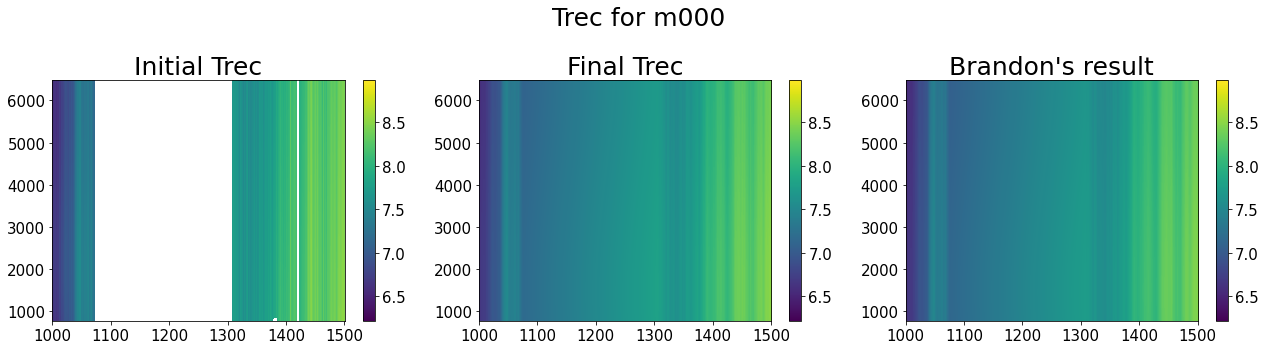

Mean residual difference to Brandon's: 0.041
Maximum residual difference to Brandon's: 0.087


In [51]:
# setting initial quantities
good_antennas_new = []

# iterating over all good antennas
for i,ant in enumerate(DR.good_antennas):
    
    # interpolating calibration
    try:
        TrecH_interp, idxH = DR.correct_Trec(Trec=Trec[i][0],mask=mask[i])
        TrecV_interp, idxV = DR.correct_Trec(Trec=Trec[i][1],mask=mask[i])
    except (ZeroDivisionError, ValueError):
        print("\tAntenna {} has bad receiver data!".format(ant))
        continue

    # creating dictionary of data
    Trec_ant = {}
    Trec_ant["H"],Trec_ant["V"] = Trec[i][0],Trec[i][1]
    Trec_ant["H_interp"],Trec_ant["V_interp"] = TrecH_interp,TrecV_interp
    Trec_ant["Hidx"],Trec_ant["Vidx"] = idxH,idxV
    good_antennas_new.append(ant)

    # getting old result
    path = "/idia/projects/hi_im/satellite_rfi/Observations/{}/{}_S1_{}_t_rec.p".format(pm.block,pm.block,ant)
    old_data = pickle.load(open(path,"rb"), encoding="latin1")["h-pol_interp"]

    # plotting newfound interpolated matrices
    extent = [DR.frequency_cut[0], DR.frequency_cut[-1], DR.nd_s0[0], DR.nd_s0[-1]]
    vmin = min(np.ma.min(np.ma.masked_equal(Trec_ant["H"],0)), np.min(Trec_ant["H_interp"]))
    vmax = max(np.max(Trec_ant["H"]), np.max(Trec_ant["H_interp"]))
    fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(18, 5))
    im1 = ax1.imshow(np.ma.masked_equal(Trec_ant["H"],0),aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im1, ax=ax1)
    ax1.set_title("Initial Trec")
    im2 = ax2.imshow(Trec_ant["H_interp"],aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im2, ax=ax2)
    ax2.set_title("Final Trec")
    im3 = ax3.imshow(old_data,aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im3, ax=ax3)
    ax3.set_title("Brandon's result")
    plt.suptitle("Trec for {}".format(ant))
    plt.tight_layout()
    plt.show()
    print("Mean residual difference to Brandon's: {:.3f}".format(np.mean(Trec_ant["H_interp"]-old_data)))
    print("Maximum residual difference to Brandon's: {:.3f}".format(np.max(Trec_ant["H_interp"]-old_data)))

    # saving data
    pickle.dump(Trec_ant, open(pm.path_cali + "{}_Trec.p".format(ant),"wb"))
DR.good_antennas = good_antennas_new


### B. Galactic temperature

For the galactic temperature we don't require any further calibration and so just save the results we already have from the calibration.

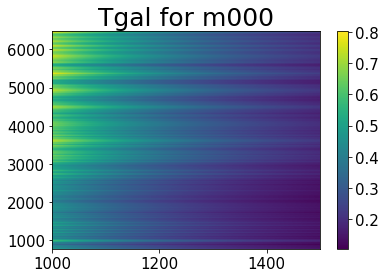

In [52]:
# iterating over each antenna
for i,ant in enumerate(DR.good_antennas):
    Tgal_ant = {}
    Tgal_ant["H"] = Tgal[i][0]
    Tgal_ant["V"] = Tgal[i][1]
    pickle.dump(Tgal_ant, open(pm.path_cali + "{}_Tgal.p".format(ant),"wb"))

    # plotting
    extent = [DR.frequency_cut[0], DR.frequency_cut[-1], DR.nd_s0[0], DR.nd_s0[-1]]
    plt.imshow(np.ma.masked_equal(Tgal_ant["H"],0),aspect="auto",origin="lower",extent=extent)
    plt.colorbar()
    plt.title("Tgal for {}".format(ant))
    plt.show()


### C. Elevation temperature

Now we do the same thing with the elevation temperature; in this case, if we find a weird bump in the data (a "spike") in the time domain, we interpolate the spiked data (because as the antennas are stationary there should not be any noticeable variation in the elevation temperature with time). 

In [55]:
# iterating over each antenna
print("Getting elevation temperatures...")
for i,ant in enumerate(DR.good_antennas):

    # getting data
    path = "/idia/projects/hi_im/satellite_rfi/misc_data/T_elevation_jobs/{}_{}".format(pm.block,ant)
    dataH = pickle.load(open(path + "h_full_t_el", "rb"), encoding="latin1")
    dataV = pickle.load(open(path + "v_full_t_el", "rb"), encoding="latin1")

    # creating dictionary
    Tel_ant = {}
    Tel_ant["H"] = dataH['Tel_map'][DR.ifreq[0]:DR.ifreq[1], DR.nd_s0_pos].T
    Tel_ant["V"] = dataV['Tel_map'][DR.ifreq[0]:DR.ifreq[1], DR.nd_s0_pos].T
    Tel_ant["H_interp"],spike_foundH = DR.correct_Tel(Tel_ant["H"])
    Tel_ant["V_interp"],spike_foundV = DR.correct_Tel(Tel_ant["V"])
    if spike_foundH or spike_foundV:  print("\tAntenna {} had 1 spike.".format(ant))

    # saving data
    pickle.dump(Tel_ant, open(pm.path_cali + "{}_Tel.p".format(ant),"wb"))


Getting elevation temperatures...


## 4. Calibrating antennas' visibilities and gain

Now we perform the calibration on the raw visibility files, to calibrate the RFI-flagged region as well. This part of the code is where the original notebook chose only to calibrate the first available antenna, and so we will just iterate over all antennas the procedure that he previously performed only on the first, assuming that we can generalize for all of them.


### A. Retrieving initial quantities and plotting

It would be probably better to divide this first section into the visibilities and gains, and to delete several of these quantities, but I'm not sure yet which quantities will be useful overall and which quantities are just for one or other plot.

**NOTE: in here Brandon uses the "Inten_mask" from the "level 4" mask, but in the final files he doesn't use it. What mask is this?**

In [ ]:
# creating quantities -- we now are storing quantities in dictionaries
visH = {}
visV = {}
gainH = {}
gainV = {}
mask = {}

# iterating over each antenna and saving
for i,ant in enumerate(DR.good_antennas):
    print(f"Getting antenna no.{i} - {ant}...")
    visH[ant], visV[ant], gainH[ant], gainV[ant], mask[ant] = DR.get_gain_raws(ant)
    

In [ ]:
# plotting raw visibilities
for i,ant in enumerate(DR.good_antennas):
    
    # defining quantities
    extent = [DR.frequency[DR.ifreq[0]], DR.frequency[DR.ifreq[1]], DR.nd_s0[-1], DR.nd_s0[0]]
    vmax,vmin = np.ma.max([visH[ant],visV[ant]]), np.ma.min([visH[ant],visV[ant]])
    labels = ["HH","VV"]
    
    # plotting raw visibilities
    fig,axs = plt.subplots(figsize=(12, 4), ncols=2, nrows=1)
    for i,vis in enumerate([visH[ant],visV[ant]]):
        plt = axs[i].imshow(vis, aspect='auto', extent=extent, vmax=vmax, vmin=vmin)
        cb = fig.colorbar(pos, ax=ax)
        cb.set_label('Raw visbility amplitude', size=12, rotation=270, labelpad=14)
        axs[i].set_title('{} polarisation'.format(labels[i]))
        axs[i].set_ylabel('Time [seconds]')
        axs[i].set_xlabel('Frequency [MHz]')

    # creating figure
    fig.suptitle("{}: Raw visibility maps for {}".format(block,ant), y=1.04)
    fig.tight_layout()
    plt.show()


In [ ]:
# plotting minimum raw visibilities
for i,ant in enumerate(DR.good_antennas):

    # calculating necessary quantities
    freq = DR.frequency[DR.ifreq[0],DR.ifreq[1]]
    visH_min = np.ma.min(visH[ant][DR.nd_s0_pos, DR.ifreq[0]:DR.ifreq[1]], axis=0)
    visV_min = np.ma.min(visV[ant][DR.nd_s0_pos, DR.ifreq[0]:DR.ifreq[1]], axis=0)
    
    # plotting
    fig,ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=1)
    ax.plot(freq, visH_min, label="HH")
    ax.plot(freq, visV_min, label="VV")
    ax.set_ylabel('Raw visibility units')
    ax.set_xlabel('Frequency [MHz]')
    ax.set_title("{}: Raw visibility maps for {}".format(block,ant), y=1.04)
    ax.legend()
    fig.tight_layout()
    plt.show()


### B. Calculating frequency bandpass for the visibility

We now perform the visibility calibration, performing a polynomial fit to the data and removing outliers iteratively.

In [ ]:
# saving quantities
bpH = {}
bpV = {}

for i,ant in enumerate(DR.good_antennas):

    # calculating bandpass and plot quantities
    bpH[ant] = DR.get_f_bandpass(vis=visH[ant], smooth=[5e4, 8e3, 1e3, 1e3])
    bpV[ant] = DR.get_f_bandpass(vis=visV[ant], smooth=[5e4, 8e3, 1e3, 1e3])

    # plotting quantities
    visH_min = np.ma.min(visH[ant][DR.nd_s0_pos, DR.ifreq[0]:DR.ifreq[1]], axis=0)
    visV_min = np.ma.min(visV[ant][DR.nd_s0_pos, DR.ifreq[0]:DR.ifreq[1]], axis=0)
    vis_min = [visH_min, visV_min]
    freq = DR.frequency[DR.ifreq[0]:DR.ifreq[1]]
    labels = ["HH","VV"]

    # plotting
    fig,axs = plt.subplots(figsize=(12, 6), nrows=2, ncols=1, sharex=True)
    for i,bp in enumerate([bpH[ant],bpV[ant]]):
        axs[i].plot(freq, bp, "b--", label="{} $4^{th}$ Spline".format(labels[i]))
        axs[i].plot(freq, vis_min[i], "r-", alpha=0.4, label=labels[i])
        axs[i].set_ylabel('Raw visibility units')
        axs[i].legend()

    # creating figure
    axs[1].set_xlabel("Frequency [MHz]")
    fig.suptitle(r"{}: 4$^{th}$ spline iteration for {}".format(block,ant), y=1.04))
    fig.tight_layout()
    plt.show()


### C. Calculating final gain curve

We now calculate the final gain curve. The original notebook also performs a lot of additional calculations and plots but none of those quantities are saved in the final file, and so we will skip these for now.

In [ ]:
for i,ant in enumerate(DR.good_antennas):

    # initial quantities
    gains = [gainH[ant], gainV[ant]]
    bps = [bpH[ant], bpV[ant]]
    norms = [0.98, 0.94]
    freq_slice = [(1138,1307), (1100,1314)]
    labels = ["HH","VV"]
    data = {}

    for i in range(len(gains)):

        # calculating final gain curve
        gain_interp = DR.combine_gain_curves(
            gains[i], norms[i]*bps[i], freq_slices[i], smoothing=0.04)

        # figure 1 -- plotting the 2 curves that we're combining
        gain = np.ma.mean(gains[i], axis=0)
        gain = gain / np.ma.max(gain)
        bp = bps[i] * norms[i] / np.ma.max(bps[i])
        fig, ax = plt.subplots(figsize=(10,4), nrows=1, ncols=1)
        ax.plot(DR.frequency, gain, 'b', alpha=0.5, label='{}: gain'.format(labels[i]))
        ax.plot(DR.frequency_cut, bp, 'b--', label='{}: bandpass'.format(labels[i]))
        ax.set_title('Normalized gain curve')
        ax.set_xlabel('Frequency [MHz]')
        ax.set_ylabel(r'$\frac{X}{max(X*)}$')
        ax.legend()
        fig.tight_layout()
        plt.show()

        # saving results
        data[labels[i]] = gain_interp(DR.frequency_cut)
    data["frequency"] = DR.frequency_cut
    pickle.dump(data, open(path_results + "{}_fbandpass.p".format(ant), "wb"))
        

## 5. Creating final obs and obs_BG

Now we perform the last calculations, to obtain the quantities that are saved in the only file that we use in the simulation. The final file that has the quantities we need is called `_average_TOD_BG_model.p` and essentially just joins in a dictionary two quantities that are originally stored in the files `_gain_tod.p` and `_bg_model_no_con.p`. These will be the parts of the code that we rewrite, and the rest we'll leave untouched as it is not necessary.

### A. Building the final observations (`_gain_tod.p`)

We start by building the final gain files (which are the observations), and for this we use the previously calculated frequency bandpass. The other quantities are not used because they were initially uploaded with slightly different masks --- check if these are relevant or if I can use the same gain and visibility that I had already uploaded before.

In [ ]:
for i,ant in enumerate(DR.good_antennas):

    # getting values and saving
    obs = DR.final_observations(ant, path_results)
    pickle.dump(obs, open(f"{path_results}{ant}_observations.p", "wb"))
    

### B. Building the final background (`_bg_model_no_con.p`)

Now we do the background, which is simply the sum of each different component.

In [ ]:
for i,ant in enumerate(DR.good_antennas):

    # getting values and saving
    BG = DR.final_background(ant, path_results)
    pickle.dump(BG, open(f"{path_results}{ant}_background.p", "wb"))
    

### C. Building the constant factor for each antenna (`temp_residual`)

There is one more thing that needs to be added, which is the constant factor in each background temperature; it will differ by antenna. Up to this moment we have not considered this aspect (it was originally calculated at the same time as the functions .TOD() and .conversion(), but for celerity we'd excluded a lot of computations. As such, now we either change that function or, if it is a lot of independent computations, we write a new function for this constant value.

**NOTE: This is mostly done in A's function but needs objects from B, so the best thing is to put all A,B,C together in a single function and call it a day.**